In [2]:
# Je declare que ce code est de moi, et que je n'ai pas copié d'autres personnes.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets   import make_blobs
from sklearn.metrics import accuracy_score
import seaborn as sns 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.datasets   import make_circles
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [3]:
np.random.seed(42)  # Pour la reproductibilité

experience_years = np.random.randint(0, 15, size=1000)  # Expérience entre 0 et 14 ans
projet = np.random.randint(0, 10, size=1000)           # Nombre de projets entre 0 et 9

# Règle simple : embaucher si experience + projet > 12, sinon non
embaucher = np.where(experience_years + projet > 12, 1, 0)

dat = {
    'experience_years': experience_years.tolist(),
    'projet': projet.tolist(),
    'embaucher': embaucher.tolist()
}

# Affichage rapide des 10 premiers exemples
for i in range(10):
    print(f"Exp: {dat['experience_years'][i]}, Projet: {dat['projet'][i]}, Embaucher: {dat['embaucher'][i]}")

Exp: 6, Projet: 0, Embaucher: 0
Exp: 3, Projet: 2, Embaucher: 0
Exp: 12, Projet: 3, Embaucher: 1
Exp: 14, Projet: 0, Embaucher: 1
Exp: 10, Projet: 0, Embaucher: 0
Exp: 7, Projet: 7, Embaucher: 1
Exp: 12, Projet: 1, Embaucher: 1
Exp: 4, Projet: 7, Embaucher: 0
Exp: 6, Projet: 6, Embaucher: 0
Exp: 9, Projet: 9, Embaucher: 1


# Data

In [4]:
data=pd.DataFrame(dat)
x=data[['experience_years','projet']].to_numpy()
y=data['embaucher'].to_numpy()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape, y_train.shape, x_test.shape, y_test.shape
class_names=['embaucher','ne pas embaucher']
data.head()


,experience_years,projet,embaucher
0,6,0,0
1,3,2,0
2,12,3,1
3,14,0,1
4,10,0,0


# Model

In [5]:
model=Sequential([
    Dense(32, activation='sigmoid', input_shape=(x_train.shape[1],)),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

c:\Users\hp\Desktop\tous\ML\env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Entrainement

In [6]:
h=model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.5781 - loss: 0.7695 - val_accuracy: 0.5813 - val_loss: 0.6910
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5781 - loss: 0.6705 - val_accuracy: 0.5813 - val_loss: 0.6436
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5781 - loss: 0.6393 - val_accuracy: 0.5813 - val_loss: 0.6244
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6406 - loss: 0.6238 - val_accuracy: 0.6812 - val_loss: 0.6123
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7359 - loss: 0.6125 - val_accuracy: 0.7375 - val_loss: 0.6016
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7891 - loss: 0.6022 - val_accuracy: 0.8062 - val_loss: 0.5916
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8344 - loss: 0.5921 - val_accuracy: 0.8562 - val_loss: 0.5821
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8672 - loss: 0.5830 - val_accuracy: 0.9062 - val_

# Evaluation

In [7]:
loss, accuracy=model.evaluate(x_test, y_test)
loss, accuracy

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8550 - loss: 0.4321  


(0.4321042597293854, 0.8550000190734863)

In [8]:
proba=model.predict(np.array([[10,3]]))
clas=(proba>0.5).astype("int32")
proba, clas

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


(array([[0.59783375]], dtype=float32), array([[1]], dtype=int32))

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (528.00 B)

 Trainable params: 129 (516.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

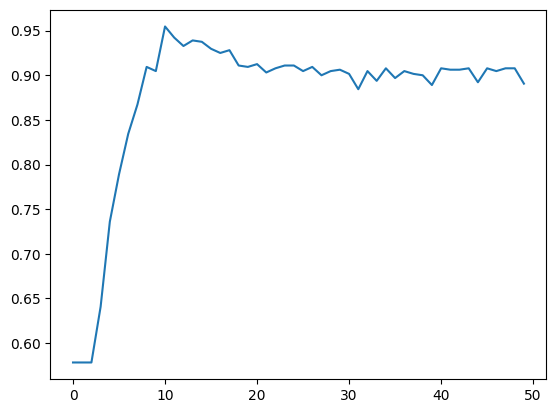

In [10]:
loss=h.history['loss']
accuracy=h.history['accuracy']
plt.plot(accuracy, label='accuracy')


# Mnist

In [11]:
mnist=pd.read_csv('mnist.csv')
xm=mnist.drop(['names','labels'],axis=1).to_numpy()
ym=mnist[['labels']].to_numpy()
xm.shape, ym.shape


((29900, 784), (29900, 1))

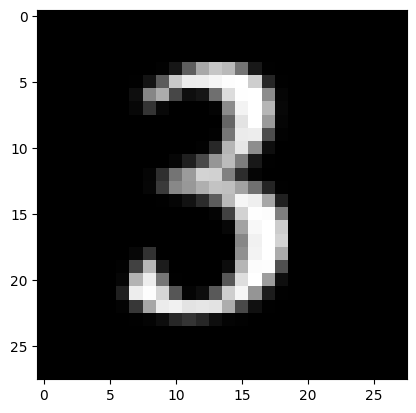

In [12]:
plt.imshow(xm[3].reshape(28,28), cmap='gray')

In [13]:
mnist['labels'].value_counts()

labels
2    2990
8    2990
4    2990
3    2990
1    2990
6    2990
5    2990
9    2990
7    2990
0    2990
Name: count, dtype: int64

In [14]:
xm_train,xm_test,ym_train,ym_test=train_test_split(xm,ym,test_size=0.2,random_state=42)
xm_train.shape, ym_train.shape, xm_test.shape, ym_test.shape

((23920, 784), (23920, 1), (5980, 784), (5980, 1))

In [15]:
xm_train=np.array(xm_train,dtype='float32')/255 # normalisation
xm_test=np.array(xm_test,dtype='float32')/255 # normalisation
ym_train = np.array(ym_train, dtype=np.int32)
ym_test = np.array(ym_test, dtype=np.int32)


In [16]:
xm_train[3]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

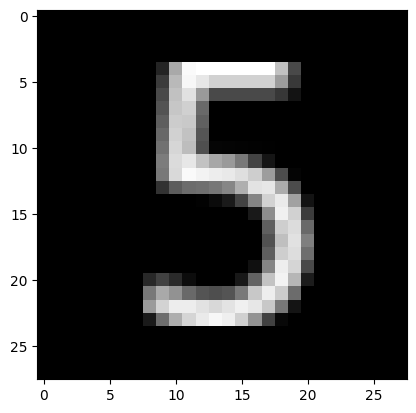

In [17]:
plt.imshow(xm_train[3].reshape(28,28), cmap='gray')

# Model

In [18]:
# on 10 class donc dernier couche 10 neurones avec softmax
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

mnist_model = Sequential([
    Dense(512, activation='relu', input_shape=(xm_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
   
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
  
    Dense(256, activation='relu'),
   
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

mnist_model.compile(optimizer=Adam(learning_rate=0.3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

c:\Users\hp\Desktop\tous\ML\env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Entrainement

In [19]:
history=mnist_model.fit(xm_train, ym_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
598/598 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.1687 - loss: 8.3084 - val_accuracy: 0.1375 - val_loss: 272.8190
Epoch 2/100
598/598 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.2327 - loss: 4.4668 - val_accuracy: 0.1536 - val_loss: 1876.3049
Epoch 3/100
598/598 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.2040 - loss: 6.4859 - val_accuracy: 0.0698 - val_loss: 4196203520.0000
Epoch 4/100
598/598 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.1579 - loss: 22.5024 - val_accuracy: 0.1672 - val_loss: 39459.1680
Epoch 5/100
598/598 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.1934 - loss: 3.3687 - val_accuracy: 0.2046 - val_loss: 6.6282
Epoch 6/100
 35/598 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.1858 - loss: 3.3983

KeyboardInterrupt: 

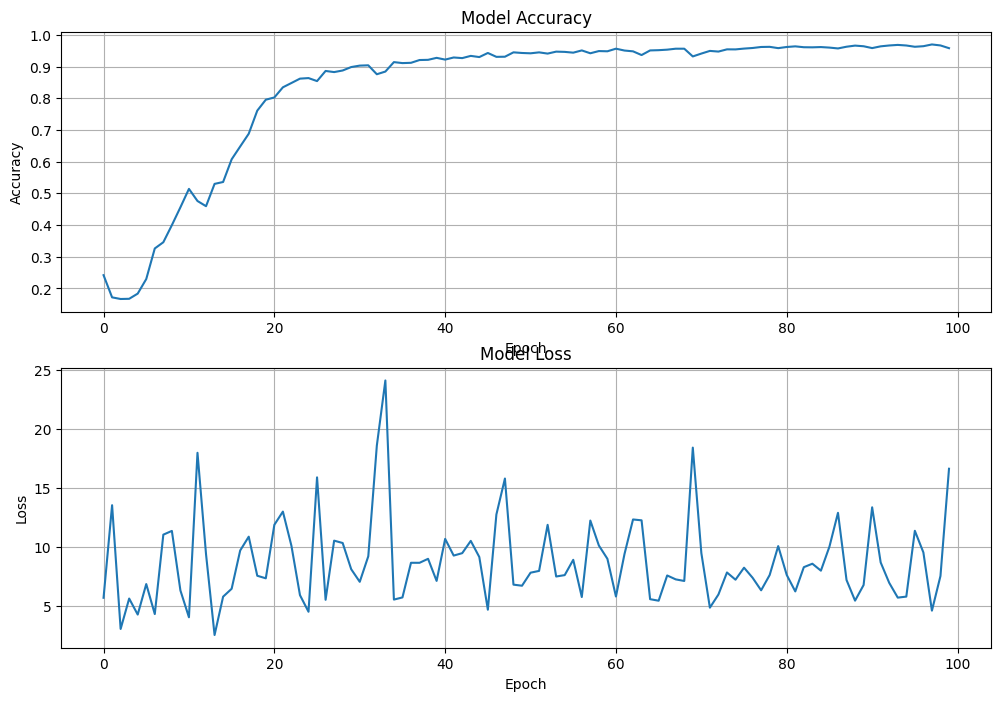

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(2,1,1)
plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.subplot(2,1,2)
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

In [ ]:
loss, accuracy = mnist_model.evaluate(xm_test, ym_test)
loss, accuracy

187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9753 - loss: 8873702.0000


(8873702.0, 0.9752508401870728)

In [ ]:
prob=mnist_model.predict(xm_test[0,:].reshape(1,784))
class_index=np.argmax(prob)
class_index

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


np.int64(3)

In [ ]:
ym_test[0,:]

array([3], dtype=int32)

In [20]:
import tensorflow as tf
tds=tf.keras.utils.image_dataset_from_directory(
    'images',
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    batch_size=32,
    color_mode='rgb',
)

Found 6 files belonging to 2 classes.


(6, 128, 128, 3)
[0 1 1 1 0 0]


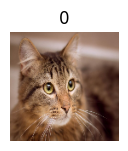

In [21]:
for images, labels in tds:
    print(images.shape)
    print(labels.numpy())
    for i in range(1):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"),cmap='gray')
        plt.title(int(labels.numpy()[i]))
        plt.axis("off")

In [22]:
mmode=tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(2, activation='sigmoid')
])
mmode.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h=mmode.fit(tds, epochs=10)

c:\Users\hp\Desktop\tous\ML\env\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.6964
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.5000 - loss: 0.9095
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.5000 - loss: 0.7791
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.5000 - loss: 0.6158
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 1.0000 - loss: 0.4795
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 1.0000 - loss: 0.3803
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 1.0000 - loss: 0.2905
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 1.0000 - loss: 0.1851
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 1.0000 - loss: 0.1065
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 1.0000 - loss: 0.0452


In [23]:
mmode.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,914,696 (37.82 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,609,798 (25.21 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
[0.15982066 0.93875176]


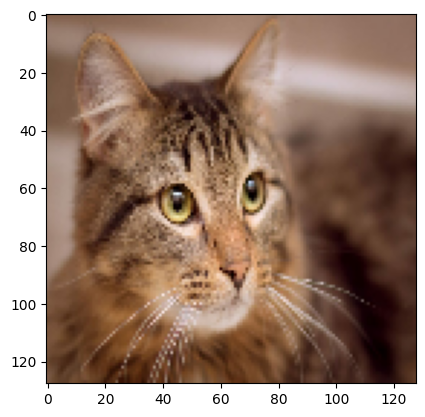

In [24]:
pred=mmode.predict(tds.take(1))[0]
print(pred)
plt.imshow(images[0].numpy().astype("uint8"),cmap='gray')

In [38]:
input_img=tf.keras.utils.load_img('images\chat\IMG_4432.jpg', color_mode="rgb")
img_rr=tf.keras.utils.img_to_array(input_img)
img_rr=np.array(img_rr)
img_rr.shape

(667, 1000, 3)

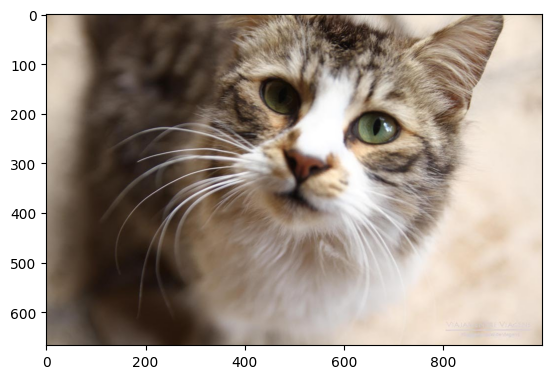

In [43]:
plt.imshow(img_rr.astype("uint8"),cmap='gray')

In [54]:
img_test=tf.image.resize(img_rr, (128, 128))
img_test=np.expand_dims(img_test,axis=0)
mmode.predict(img_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step


array([[0.96279067, 0.22702706]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


array([[0.2648005, 0.8458003]], dtype=float32)

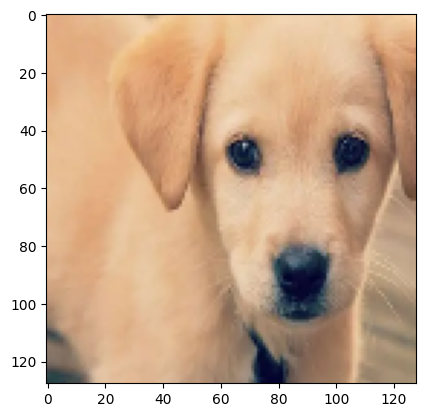

In [87]:
chien=tf.keras.utils.load_img('images\chien\chien1.jpg', color_mode="rgb")
chien=tf.image.resize(chien, (128, 128))
chien_rr=tf.keras.utils.img_to_array(chien)
single_image=np.array([chien_rr]) # avoir single img
plt.imshow(chien_rr.astype('uint8'),cmap='gray')
mmode.predict(single_image)

# Ajouter de Batch

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


array([[0.2648005, 0.8458003]], dtype=float32)